# Step 3.1.2.3: Shape Graphs可视化分析

## 目标

对Shape Graphs阵型识别结果进行可视化分析：
1. 阵型分布饼图
2. 阵型时间序列图

## 前置条件

需要先运行3.1.2.2生成结果文件

## 1. 导入库和配置

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 比赛信息
GAME_ID = 10517

# 数据路径
DATA_DIR = Path('../../../data/morph_test')
OUTPUT_DIR = DATA_DIR / 'shapegraphs_baseline'

print("✅ 配置完成")

✅ 配置完成


## 2. 加载结果数据

In [2]:
# 加载Shape Graphs阵型识别结果
results_file = OUTPUT_DIR / f'shapegraphs_baseline_results_{GAME_ID}.parquet'
results_df = pd.read_parquet(results_file)

print(f"✅ 加载结果: {len(results_df)} 帧")
print(f"\n数据列: {results_df.columns.tolist()}")
print(f"\n前5行:")
print(results_df.head())

✅ 加载结果: 50084 帧

数据列: ['frame_id', 'formation', 'formation_code', 'formation_detailed', 'n_defenders', 'n_dm', 'n_midfielders', 'n_am', 'n_forwards', 'vertical_levels', 'horizontal_positions', 'formation_smoothed', 'formation_code_smoothed', 'formation_detailed_smoothed']

前5行:
   frame_id formation formation_code formation_detailed  n_defenders  n_dm  \
0     10018     2-5-3        2(014)3              20143            1     1   
1     10019     2-5-3        2(014)3              20143            1     1   
2     10020     2-5-3        2(014)3              20143            1     1   
3     10021     2-5-3        2(014)3              20143            1     1   
4     10022     3-5-2        3(212)2              32122            3     2   

   n_midfielders  n_am  n_forwards                      vertical_levels  \
0              1     4           3  [F, DM, AM, M, F, B, AM, AM, F, AM]   
1              1     4           3  [F, DM, AM, M, F, B, AM, AM, F, AM]   
2              1     4     

## 3. 阵型分布饼图

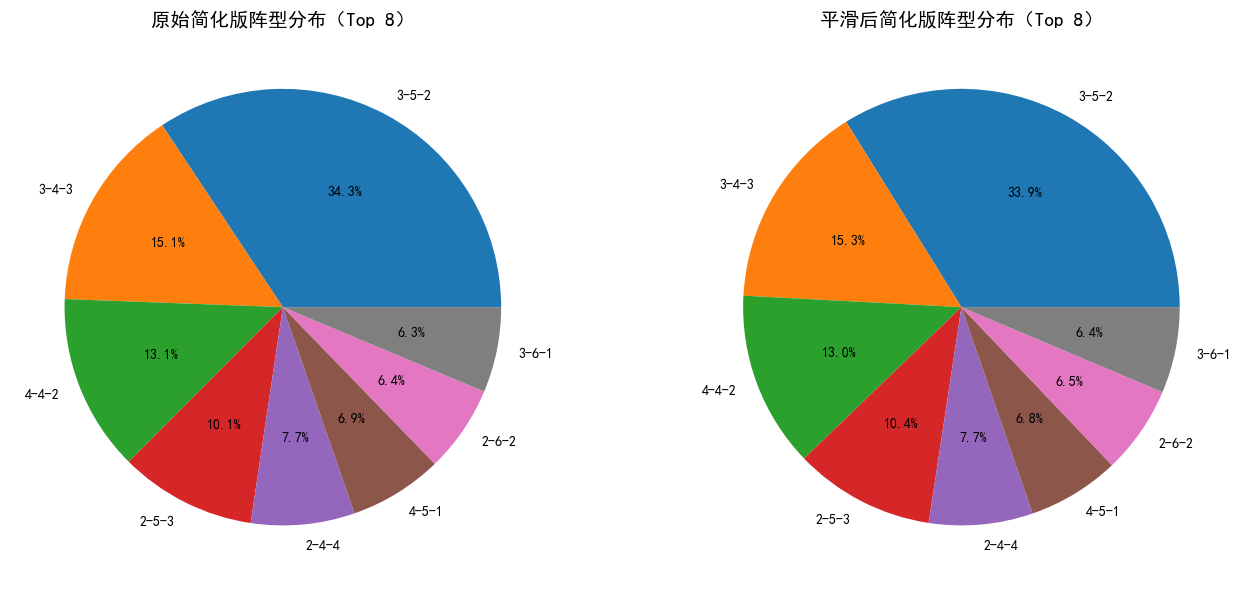

✅ 简化版阵型分布图已保存


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 原始阵型分布
formation_counts = results_df['formation'].value_counts().head(8)
axes[0].pie(formation_counts.values, labels=formation_counts.index, autopct='%1.1f%%')
axes[0].set_title('原始简化版阵型分布（Top 8）', fontsize=14, fontweight='bold')

# 平滑后阵型分布
smoothed_counts = results_df['formation_smoothed'].value_counts().head(8)
axes[1].pie(smoothed_counts.values, labels=smoothed_counts.index, autopct='%1.1f%%')
axes[1].set_title('平滑后简化版阵型分布（Top 8）', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'formation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 简化版阵型分布图已保存")

## 4. 阵型时间序列图

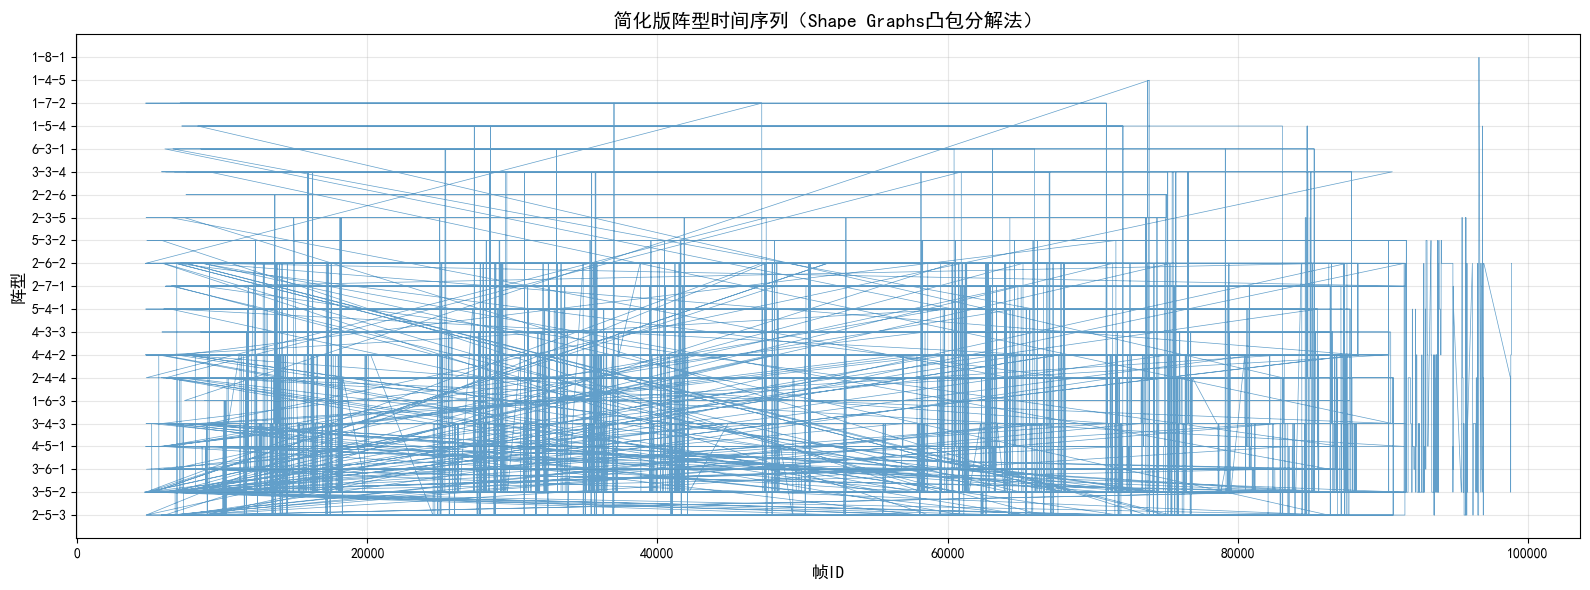

✅ 简化版阵型时间序列图已保存


In [4]:
fig, ax = plt.subplots(figsize=(16, 6))

# 为每个阵型分配一个数字ID
unique_formations = results_df['formation_smoothed'].unique()
formation_to_id = {f: i for i, f in enumerate(unique_formations)}
formation_ids = results_df['formation_smoothed'].map(formation_to_id)

# 绘制时间序列
ax.plot(results_df['frame_id'], formation_ids, linewidth=0.5, alpha=0.7)
ax.set_xlabel('帧ID', fontsize=12)
ax.set_ylabel('阵型', fontsize=12)
ax.set_title('简化版阵型时间序列（Shape Graphs凸包分解法）', fontsize=14, fontweight='bold')
ax.set_yticks(range(len(unique_formations)))
ax.set_yticklabels(unique_formations)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'formation_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 简化版阵型时间序列图已保存")

## 5. 统计摘要

In [5]:
print("=== Shape Graphs阵型识别统计摘要 ===")
print(f"\n总帧数: {len(results_df)}")
print(f"\n原始阵型数量: {results_df['formation'].nunique()}")
print(f"平滑后阵型数量: {results_df['formation_smoothed'].nunique()}")

print(f"\n最常见阵型（平滑后）:")
for formation, count in results_df['formation_smoothed'].value_counts().head(5).items():
    percentage = count / len(results_df) * 100
    print(f"  {formation}: {count} 帧 ({percentage:.1f}%)")

print(f"\n后卫数量分布:")
print(results_df['n_defenders'].value_counts().sort_index())

print(f"\n中场数量分布:")
total_midfielders = results_df['n_dm'] + results_df['n_midfielders'] + results_df['n_am']
print(total_midfielders.value_counts().sort_index())

print(f"\n前锋数量分布:")
print(results_df['n_forwards'].value_counts().sort_index())

=== Shape Graphs阵型识别统计摘要 ===

总帧数: 50084

原始阵型数量: 25
平滑后阵型数量: 21

最常见阵型（平滑后）:
  3-5-2: 15182 帧 (30.3%)
  3-4-3: 6861 帧 (13.7%)
  4-4-2: 5841 帧 (11.7%)
  2-5-3: 4668 帧 (9.3%)
  2-4-4: 3445 帧 (6.9%)

后卫数量分布:
n_defenders
1     7247
2    26589
3    11607
4     3916
5      660
6       65
Name: count, dtype: int64

中场数量分布:
3       92
4     4753
5    21357
6    21060
7     2563
8      259
Name: count, dtype: int64

前锋数量分布:
n_forwards
0        3
1     8532
2    24764
3    12067
4     4084
5      607
6       27
Name: count, dtype: int64


## 总结

本notebook完成了以下可视化分析：

1. ✅ 阵型分布饼图（原始 vs 平滑）
2. ✅ 阵型时间序列图
3. ✅ 统计摘要

输出文件：
- `formation_distribution.png` - 阵型分布饼图
- `formation_timeline.png` - 阵型时间序列图

下一步：运行3.1.2.4（原3.1.3）进行动态视频可视化